## Projeto 1 - Análise Exploratória de Dados

Neste projeto, vamos abordar conceitos de análise exploratória de dados, essenciais para conhecermos melhor o conjunto de dados que estamos trabalhando.

O _dataset_ a ser examinado apresenta um exemplo prático de um problema de classificação, envolvendo a possibilidade de sobrevivência de passageiros do titanic com base em suas características.

Vamos iniciar carregando o dataset **titanic/train.csv** em um *DataFrame* do **pandas**.

In [1]:
import pandas as pd

# Importar dados
dataset_path = "titanic/train.csv" 
titanic = pd.read_csv(dataset_path)

### Análise Univariada

Com o objetivo de verificar o conteúdo e a integridade do dataset, responda as seguintes perguntas.

1) Qual o número de features e instâncias?

    _**11 features, 891 instâncias.**_

2) Quais features são categóricas e quais são contínuas?

    _**Categóricas: Name, Sex, Ticket, Cabin, Embarked.**_
    
    _**Contínuas: PassengerID, Pclass, Age, SibSp, Parch, Fare.**_

3) Há dados faltantes em algumas das features? Se sim, em quais?

    _**Sim, em Age, Cabin e Embarked.**_

4) Em qual das features há mais notavelmente a presença de outlier?


    _**Fare.**_

5) Há mais passageiros que sobreviveram, ou não? Justifique.

    _**Há mais passageiros que não sobreviveram. Média de Survived < 0.5.**_

6) Qual a idade média dos passageiros?

    _**Média de Age: 29.699118.**_

7) Qual a classe mais comum em que os passageiros viajaram (Pclass)?

    _**Para a feature Pclass, Quartil 75%, e Máx: 3.**_


In [2]:
# 1
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
#2 #3
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >, <Axes: >]],
      dtype=object)

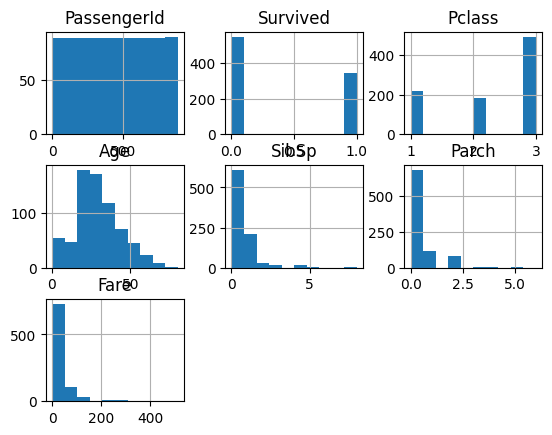

In [4]:
#4
titanic.hist()

In [5]:
#5 #6 #7
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Separação Treinamento/Teste

Para realizarmos análises exploratórias que utilizem o target para orientar decisões de modelagem, é necessário dividir o dataset nos conjuntos de treino e teste.

Desse modo, estamos garantindo que o modelo não tenha acesso indireto a informações do conjunto de teste, evitando _data leakage_.

In [6]:
### SEPARAÇÃO TREINAMENTO/TESTE ###

from sklearn.model_selection import train_test_split

titanic_train, titanic_test = train_test_split(titanic, test_size=0.2, random_state=42)

### Análise Bivariada

Responda as perguntas a seguir levando em consideração o conjunto de treino.

1) Para as features numéricas, plote a matriz de correlação linear.
2) Qual feature apresenta menor correlação com o target? Faz sentido incluí-la no treinamento?

    _**PassengerID. Idealmente ela não deve participar do treinamento, pois não carrega informação estatística.**_

3) Qual feature apresenta maior correlação com o target? Esse dado garante que ela é a feature mais importante?

    _**Pclass: -0.3384. Quanto menor a classe, mais improvável a sobrevivência. Não, pois podem haver outras relações não lineares entre as features e o target.**_  

4) Realize o boxplot conjunto entre a feature _Fare_ (valor pago no ticket) e o target. O que pode ser observado?

    _**Passageiros que sobreviveram pagaram, em média, um valor de ticket mais elevado.**_

6) Faça a tabela de contigência entre a feature _Sex_ e o target. No conjunto de treino, qual porcentagem dos sobreviventes eram Mulheres?

    _**No conjunto de treino, aproximadamente 67.5% dos sobreviventes eram Mulheres.**_


In [12]:
#1 #2 #3
titanic_train_num = titanic.drop(columns=["Name", "Sex", "Ticket", "Cabin", "Embarked"])
titanic_train_num.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<Axes: title={'center': 'Fare'}, xlabel='Survived'>

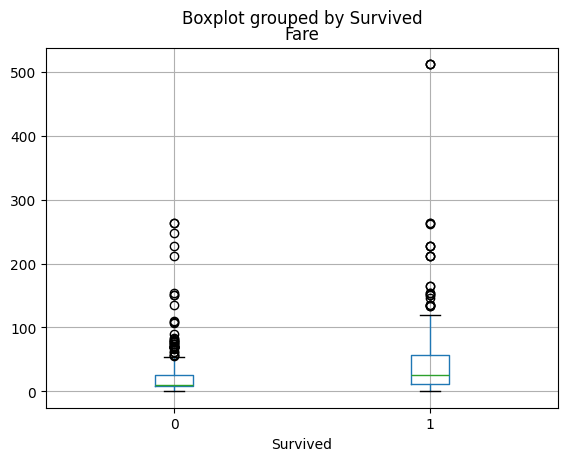

In [ ]:
#4
titanic_train.boxplot(column="Fare", by="Survived")

In [ ]:
#5
pd.crosstab(titanic_train["Sex"], titanic_train["Survived"])

Survived,0,1
Sex,,
female,64,181
male,380,87


In [ ]:
#5
181/(181+87)

0.6753731343283582